# `v_n` - `epsilon_n` 线性回归分析

这个 notebook 读取 Blast_wave 当前 ROOT 输出中的 `events` 树，做事件级线性响应分析：

\[
v_{n|\Psi_n} = \kappa_n\,\epsilon_n + c_n.
\]

默认分析两组主响应：

- `events.eps2` 对 `events.v2_wrt_psi2`
- `events.eps3` 对 `events.v3_wrt_psi3`

这里刻意使用 `v2_wrt_psi2` / `v3_wrt_psi3`，而不是 `v2` / `v3` 的模长。前者是末态 Q-vector 投影到初态 participant plane 后的带符号响应量，更适合直接检查线性响应斜率；`v2` / `v3` 是非负模长，容易把方向涨落折叠进去。

## 环境与 uproot 支持

推荐使用本目录里的 `root_notebook` conda 环境文件：

```bash
conda env create -f notebooks/environment-notebook_with_root.yml
conda activate root_notebook
python -m ipykernel install --user --name root_notebook --display-name "root_notebook"
```

这个环境只包含 `uproot`、`numpy`、`pandas`、`matplotlib`、`scipy`、`jupyterlab` 和 `ipykernel` 等 Python 分析栈，不再安装完整 ROOT/PyROOT。

本 notebook 的读取路径是 `uproot`，用于直接读取 ROOT 文件中的 `events` tree 和对象键；不需要当前 kernel 提供 `import ROOT`。

In [1]:
# Load the Python analysis stack used by the event-tree regression path.
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 6)

Matplotlib is building the font cache; this may take a moment.


## 输入文件选择与多文件对比

`INPUT_FILES` 是多文件比较入口。每一项是 `(ROOT 文件路径, 图例标签)`；同一个 notebook 会对每个文件分别读取 `events` tree、应用同一组 event cuts、做同一套 event-level linear regression，然后把结果 overlay 到比较图中。

默认候选文件优先使用 `qa/test_b8_response_023.root`、`qa/test_b8_response_023_mix.root` 和 `qa/test_b8_023_newrap.root` 中当前存在的文件。若要比较自己的扫描结果，直接把下面的 `INPUT_FILES` 改成对应文件列表即可。

注意：`qa/` 里可能有旧 schema 文件。若某个文件缺少 `events.eps2/eps3` 或 `events.v2_wrt_psi2/v3_wrt_psi3`，读取阶段会跳过该文件并打印原因。


In [ ]:
# Resolve the repository root whether the notebook is opened from repo root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Multi-file comparison input. Edit this list to compare another scan set.
# DEFAULT_INPUT_CANDIDATES = [
#     # (PROJECT_ROOT / "qa" / "test_b8_response_023.root", "response_023"),
#     (PROJECT_ROOT / "qa" / "test_023_dense.root", "dense_mix"),
#     (PROJECT_ROOT / "qa" / "test_023_newrap.root", "newrap"),
#     (PROJECT_ROOT / "qa" / "test_023_ellipse.root", "ellipse"),
# ]
DEFAULT_INPUT_CANDIDATES = [
    # (PROJECT_ROOT / "qa" / "test_b8_response_023.root", "response_023"),
    (PROJECT_ROOT / "qa" / "test_023_dense_mix_glauber.root", "dense_mix"),
    (PROJECT_ROOT / "qa" / "test_023_newrap_glauber.root", "newrap"),
    (PROJECT_ROOT / "qa" / "test_023_ellipse_glauber.root", "ellipse"),
]
INPUT_FILES = [(path, label) for path, label in DEFAULT_INPUT_CANDIDATES if path.exists()]

if not INPUT_FILES:
    candidates = sorted((PROJECT_ROOT / "qa").glob("*.root"), key=lambda path: path.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No ROOT files found under {PROJECT_ROOT / 'qa'}")
    INPUT_FILES = [(candidates[0], candidates[0].stem)]

# Plotting controls. Regression is always done on raw event rows; binned means are visual guides only.
PLOT_RAW_SCATTER = False
PROFILE_BINS = 12
SCATTER_MAX_POINTS = 20000


def normalise_input_files(entries):
    specs = []
    seen_labels = set()
    for entry in entries:
        if isinstance(entry, (str, Path)):
            path = Path(entry)
            label = path.stem
        else:
            path = Path(entry[0])
            label = str(entry[1]) if len(entry) > 1 else path.stem

        if not path.is_absolute():
            path = PROJECT_ROOT / path
        path = path.resolve()
        if not path.exists():
            print(f"[skip] {label}: file does not exist: {path}")
            continue
        if label in seen_labels:
            raise ValueError(f"Duplicate input label {label!r}; labels must be unique for comparison plots.")
        seen_labels.add(label)
        specs.append({"path": path, "label": label})

    if not specs:
        raise FileNotFoundError("No existing ROOT input files were configured.")
    return specs


input_files = normalise_input_files(INPUT_FILES)
ROOT_FILE = input_files[0]["path"]  # Backward-compatible first-file handle for optional single-file cells.

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print("Configured input files:")
for spec in input_files:
    print(f"  {spec['label']}: {spec['path']}")


PROJECT_ROOT = /Users/allenzhou/Research_software/Blast_wave
Configured input files:
  dense_mix: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_dense.root
  newrap: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_newrap.root
  ellipse: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_ellipse.root


In [3]:
# Inspect top-level objects and verify that the event tree is present in each configured file.
inspection_rows = []
for spec in input_files:
    try:
        with uproot.open(str(spec["path"])) as root_file:
            top_level_keys = [key.split(";")[0] for key in root_file.keys()]
            if "events" not in root_file:
                raise KeyError("missing required 'events' tree")
            event_tree = root_file["events"]
            event_branches = sorted(event_tree.keys())
            inspection_rows.append({
                "label": spec["label"],
                "path": str(spec["path"]),
                "top_level_objects": ", ".join(top_level_keys),
                "n_event_branches": len(event_branches),
                "event_branches": ", ".join(event_branches),
            })
    except Exception as exc:
        inspection_rows.append({
            "label": spec["label"],
            "path": str(spec["path"]),
            "top_level_objects": "",
            "n_event_branches": 0,
            "event_branches": f"ERROR: {exc}",
        })

inspection_table = pd.DataFrame(inspection_rows)
display(inspection_table)


,label,path,top_level_objects,n_event_branches,event_branches
0,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,"particles, particles, participants, participan...",27,"Nch, Npart, R_rms_init, b, centrality, chi2, e..."
1,newrap,/Users/allenzhou/Research_software/Blast_wave/...,"particles, particles, events, participants, Np...",27,"Nch, Npart, R_rms_init, b, centrality, chi2, e..."
2,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,"particles, particles, participants, participan...",27,"Nch, Npart, R_rms_init, b, centrality, chi2, e..."


## 读取 `events` 树

当前 notebook 只依赖事件级分支：

- 初态几何：`eps2`, `eps3`
- 末态投影响应：`v2_wrt_psi2`, `v3_wrt_psi3`
- 可选筛选/权重：`centrality`, `Npart`, `Nch`
- 对照观察：`v2`, `v3`

In [4]:
# Read the event-level branches needed for regression and common filters.
REQUIRED_BRANCHES = ["eps2", "eps3", "v2_wrt_psi2", "v3_wrt_psi3"]
OPTIONAL_BRANCHES = ["event_id", "centrality", "Npart", "Nch", "v2", "v3", "eps2_f", "chi2"]


def read_event_table(input_spec):
    with uproot.open(str(input_spec["path"])) as root_file:
        event_tree = root_file["events"]
        event_branches = set(event_tree.keys())
        missing_required = [branch for branch in REQUIRED_BRANCHES if branch not in event_branches]
        if missing_required:
            raise KeyError(f"missing required event branches: {missing_required}")

        branches_to_read = []
        for branch in REQUIRED_BRANCHES + OPTIONAL_BRANCHES:
            if branch in event_branches and branch not in branches_to_read:
                branches_to_read.append(branch)
        events_for_file = event_tree.arrays(branches_to_read, library="pd")
        events_for_file["source_label"] = input_spec["label"]
        return events_for_file


event_tables = {}
valid_input_files = []
read_rows = []
for spec in input_files:
    try:
        table = read_event_table(spec)
    except Exception as exc:
        print(f"[skip] {spec['label']}: {exc}")
        continue

    event_tables[spec["label"]] = table
    valid_input_files.append(spec)
    read_rows.append({"label": spec["label"], "path": str(spec["path"]), "n_events": len(table), "n_branches": len(table.columns)})

if not valid_input_files:
    raise RuntimeError("No configured ROOT files could be read with the required event-level response branches.")

input_files = valid_input_files
ROOT_FILE = input_files[0]["path"]
events = event_tables[input_files[0]["label"]]  # Backward-compatible first-file table.
read_summary = pd.DataFrame(read_rows)
display(read_summary)
display(events.head())


,label,path,n_events,n_branches
0,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,5000,13
1,newrap,/Users/allenzhou/Research_software/Blast_wave/...,5000,13
2,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,5000,13


,eps2,eps3,v2_wrt_psi2,v3_wrt_psi3,event_id,centrality,Npart,Nch,v2,v3,eps2_f,chi2,source_label
0,0.192661,0.078869,0.064402,-0.049739,0,60.422961,600,1197,0.065204,0.049859,0.192661,1.0,dense_mix
1,0.259765,0.085124,0.095582,0.013051,1,60.422961,600,1116,0.095627,0.036229,0.259765,1.0,dense_mix
2,0.132806,0.033547,0.025093,-0.036125,2,60.422961,600,1165,0.027018,0.036348,0.132806,1.0,dense_mix
3,0.155296,0.096159,0.041790,0.035027,3,60.422961,600,1236,0.066465,0.035036,0.155296,1.0,dense_mix
4,0.127421,0.156521,0.041455,0.043433,4,60.422961,600,1117,0.042359,0.043925,0.127421,1.0,dense_mix


In [5]:
# Configure event-level cuts and optional weights in one place. The same cuts are applied to every file.
CENTRALITY_RANGE = None  # Example: (0.0, 50.0)
NCH_MIN = None           # Example: 20
EPSILON_MIN = 0.0        # Raise this if near-zero epsilon events dominate numerical ratios.
WEIGHT_COLUMN = None     # Example: "Nch"; keep None for ordinary least squares.

# Apply finite-value and physics-motivated event filters before fitting.
def select_events(data: pd.DataFrame) -> pd.DataFrame:
    selected = data.copy()

    finite_columns = ["eps2", "eps3", "v2_wrt_psi2", "v3_wrt_psi3"]
    finite_mask = np.ones(len(selected), dtype=bool)
    for column in finite_columns:
        finite_mask &= np.isfinite(selected[column].to_numpy(dtype=float))
    selected = selected.loc[finite_mask]

    if CENTRALITY_RANGE is not None and "centrality" in selected:
        low, high = CENTRALITY_RANGE
        selected = selected[(selected["centrality"] >= low) & (selected["centrality"] < high)]

    if NCH_MIN is not None and "Nch" in selected:
        selected = selected[selected["Nch"] >= NCH_MIN]

    if EPSILON_MIN > 0.0:
        selected = selected[(selected["eps2"] >= EPSILON_MIN) & (selected["eps3"] >= EPSILON_MIN)]

    return selected.reset_index(drop=True)


selected_events_by_file = {}
selection_rows = []
for spec in input_files:
    label = spec["label"]
    selected = select_events(event_tables[label])
    selected_events_by_file[label] = selected
    selection_rows.append({"label": label, "input_events": len(event_tables[label]), "selected_events": len(selected)})

selected_events = selected_events_by_file[input_files[0]["label"]]  # Backward-compatible first-file selection.
selection_summary = pd.DataFrame(selection_rows)
display(selection_summary)
display(selected_events.describe().T)


,label,input_events,selected_events
0,dense_mix,5000,5000
1,newrap,5000,5000
2,ellipse,5000,5000


,count,mean,std,min,25%,50%,75%,max
eps2,5000.0,0.179901,3.960723e-02,0.025756,0.152600,0.180796,0.207237,0.301021
eps3,5000.0,0.076863,4.000021e-02,0.000564,0.047016,0.072322,0.102491,0.266574
v2_wrt_psi2,5000.0,0.036318,2.841164e-02,-0.082544,0.017331,0.036656,0.055442,0.149355
v3_wrt_psi3,5000.0,0.012336,2.643171e-02,-0.079882,-0.005068,0.012488,0.029826,0.116843
event_id,5000.0,2499.500000,1.443520e+03,0.000000,1249.750000,2499.500000,3749.250000,4999.000000
centrality,5000.0,60.422961,7.106138e-15,60.422961,60.422961,60.422961,60.422961,60.422961
Npart,5000.0,600.000000,0.000000e+00,600.000000,600.000000,600.000000,600.000000,600.000000
Nch,5000.0,1199.520400,5.273060e+01,1021.000000,1164.000000,1199.000000,1234.000000,1460.000000
v2,5000.0,0.050313,2.358523e-02,0.001418,0.032596,0.049021,0.065780,0.149780
v3,5000.0,0.034766,1.809367e-02,0.000152,0.021349,0.032491,0.046244,0.122979


## 回归实现

下面的 helper 使用普通最小二乘或可选加权最小二乘。默认报告两类斜率：

- `slope_free_intercept`: 拟合 `v = slope * eps + intercept`
- `slope_through_origin`: 强制过原点的响应斜率，近似对应理想线性响应里的 `kappa_n`

如果自由截距接近 0，过原点斜率通常更容易解释；如果自由截距明显偏离 0，应优先检查低 multiplicity、centrality 混合或模型里是否存在非线性/背景偏置。

In [6]:
# Solve a linear least-squares model and return compact diagnostics.
def linear_fit(x_values, y_values, weights=None, *, intercept=True):
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(y_values, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    if weights is not None:
        w = np.asarray(weights, dtype=float)
        mask &= np.isfinite(w) & (w > 0.0)
        w = w[mask]
    else:
        w = np.ones(np.count_nonzero(mask), dtype=float)

    x = x[mask]
    y = y[mask]
    if x.size < (2 if intercept else 1):
        raise ValueError("Not enough finite points for linear regression.")

    design = np.column_stack([np.ones_like(x), x]) if intercept else x[:, None]
    sqrt_w = np.sqrt(w)
    weighted_design = design * sqrt_w[:, None]
    weighted_y = y * sqrt_w

    beta, *_ = np.linalg.lstsq(weighted_design, weighted_y, rcond=None)
    fitted = design @ beta
    residuals = y - fitted

    n_points = x.size
    n_params = design.shape[1]
    dof = max(n_points - n_params, 0)
    ss_res = float(np.sum(w * residuals * residuals))
    y_mean = float(np.average(y, weights=w))
    ss_tot = float(np.sum(w * (y - y_mean) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0.0 else np.nan

    normal_matrix = weighted_design.T @ weighted_design
    sigma2 = ss_res / dof if dof > 0 else np.nan
    covariance = np.linalg.pinv(normal_matrix) * sigma2 if np.isfinite(sigma2) else np.full((n_params, n_params), np.nan)
    stderr = np.sqrt(np.diag(covariance))

    if intercept:
        intercept_value = float(beta[0])
        slope_value = float(beta[1])
        intercept_stderr = float(stderr[0])
        slope_stderr = float(stderr[1])
    else:
        intercept_value = 0.0
        slope_value = float(beta[0])
        intercept_stderr = np.nan
        slope_stderr = float(stderr[0])

    pearson_r = float(np.corrcoef(x, y)[0, 1]) if n_points > 1 and np.std(x) > 0.0 and np.std(y) > 0.0 else np.nan

    return {
        "n": int(n_points),
        "intercept": intercept_value,
        "intercept_stderr": intercept_stderr,
        "slope": slope_value,
        "slope_stderr": slope_stderr,
        "r2": r2,
        "pearson_r": pearson_r,
        "rmse": math.sqrt(ss_res / n_points),
        "residuals": residuals,
        "fitted": fitted,
    }

# Compute binned means for plotting the response trend over noisy event scatter.
def binned_profile(x_values, y_values, *, bins=12):
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(y_values, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size == 0 or np.nanmin(x) == np.nanmax(x):
        return pd.DataFrame(columns=["x", "y", "yerr", "count"])

    edges = np.linspace(float(np.nanmin(x)), float(np.nanmax(x)), bins + 1)
    bin_index = np.digitize(x, edges, right=False) - 1
    bin_index = np.clip(bin_index, 0, bins - 1)

    rows = []
    for index in range(bins):
        in_bin = bin_index == index
        if not np.any(in_bin):
            continue
        y_bin = y[in_bin]
        rows.append({
            "x": float(np.mean(x[in_bin])),
            "y": float(np.mean(y_bin)),
            "yerr": float(np.std(y_bin, ddof=1) / math.sqrt(y_bin.size)) if y_bin.size > 1 else 0.0,
            "count": int(y_bin.size),
        })
    return pd.DataFrame(rows)

In [7]:
# Run same-harmonic response fits for each file and summarize free-intercept and through-origin slopes.
RESPONSE_PAIRS = {
    "n=2 response": {"epsilon": "eps2", "response": "v2_wrt_psi2", "harmonic": 2},
    "n=3 response": {"epsilon": "eps3", "response": "v3_wrt_psi3", "harmonic": 3},
}


def weights_for(data: pd.DataFrame):
    if WEIGHT_COLUMN is None:
        return None
    if WEIGHT_COLUMN not in data:
        raise KeyError(f"WEIGHT_COLUMN={WEIGHT_COLUMN!r} is not present in the events table.")
    return data[WEIGHT_COLUMN].to_numpy(dtype=float)


def fit_pair_set(pair_specs: dict, *, include_origin=True):
    all_results = {pair_label: {} for pair_label in pair_specs}
    rows = []

    for input_spec in input_files:
        file_label = input_spec["label"]
        data = selected_events_by_file[file_label]
        weights = weights_for(data)

        for pair_label, spec in pair_specs.items():
            x = data[spec["epsilon"]].to_numpy(dtype=float)
            y = data[spec["response"]].to_numpy(dtype=float)
            fit_free = linear_fit(x, y, weights=weights, intercept=True)
            fit_origin = linear_fit(x, y, weights=weights, intercept=False) if include_origin else None

            result = {"free": fit_free, "origin": fit_origin, "file_label": file_label, "pair_label": pair_label, **spec}
            all_results[pair_label][file_label] = result

            row = {
                "file_label": file_label,
                "file_path": str(input_spec["path"]),
                "label": pair_label,
                "n_events": fit_free["n"],
                "epsilon": spec["epsilon"],
                "response": spec["response"],
                "slope_free_intercept": fit_free["slope"],
                "slope_free_stderr": fit_free["slope_stderr"],
                "intercept": fit_free["intercept"],
                "intercept_stderr": fit_free["intercept_stderr"],
                "r2_free": fit_free["r2"],
                "pearson_r": fit_free["pearson_r"],
                "rmse_free": fit_free["rmse"],
            }
            if fit_origin is not None:
                row.update({
                    "slope_through_origin": fit_origin["slope"],
                    "slope_origin_stderr": fit_origin["slope_stderr"],
                    "rmse_origin": fit_origin["rmse"],
                })
            rows.append(row)

    return all_results, pd.DataFrame(rows)


fit_results, summary = fit_pair_set(RESPONSE_PAIRS, include_origin=True)
display(summary)


,file_label,file_path,label,n_events,epsilon,response,slope_free_intercept,slope_free_stderr,intercept,intercept_stderr,r2_free,pearson_r,rmse_free,slope_through_origin,slope_origin_stderr,rmse_origin
0,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,n=2 response,5000,eps2,v2_wrt_psi2,0.204500,0.009726,-0.000471,0.001792,0.081272,0.285083,0.027230,0.202001,0.002091,0.027230
1,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,n=3 response,5000,eps3,v3_wrt_psi3,0.140775,0.009132,0.001515,0.000791,0.045386,0.213041,0.025822,0.156289,0.004217,0.025832
2,newrap,/Users/allenzhou/Research_software/Blast_wave/...,n=2 response,5000,eps2,v2_wrt_psi2,0.155738,0.008892,-0.006289,0.001910,0.057830,0.240478,0.035047,0.127457,0.002311,0.035085
3,newrap,/Users/allenzhou/Research_software/Blast_wave/...,n=3 response,5000,eps3,v3_wrt_psi3,0.109841,0.009284,0.000324,0.001013,0.027243,0.165056,0.032962,0.112479,0.004272,0.032962
4,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,n=2 response,5000,eps2,v2_wrt_psi2,0.256482,0.008791,-0.008294,0.001819,0.145519,0.381470,0.025040,0.217173,0.001715,0.025092
5,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,n=3 response,5000,eps3,v3_wrt_psi3,-0.133320,0.008804,-0.000110,0.000682,0.043867,-0.209444,0.022508,-0.134577,0.004110,0.022508


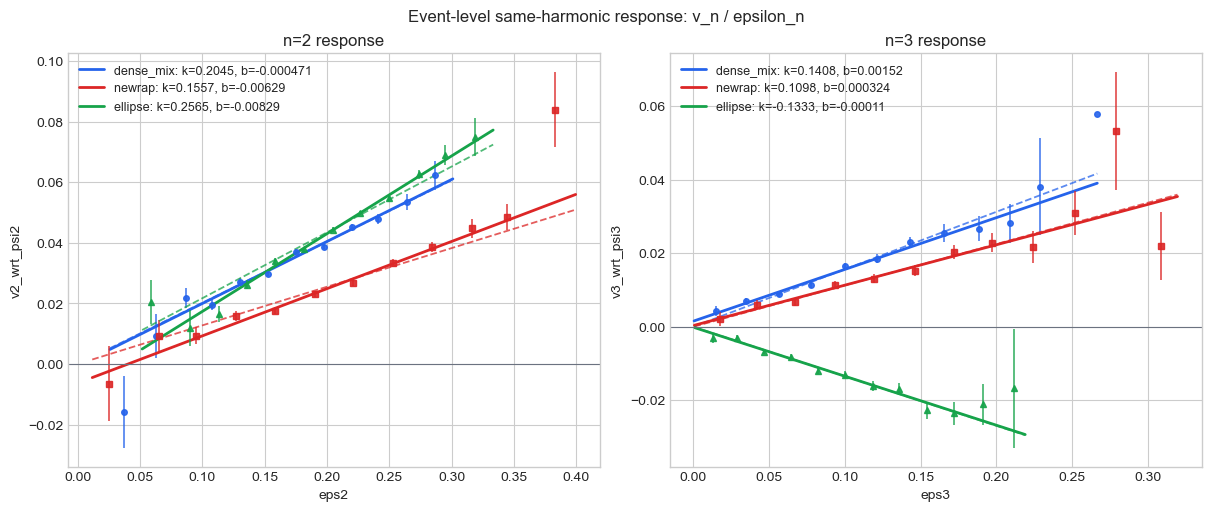

In [8]:
# Plot raw-event regression comparisons. Binned means are visual guides and do not enter the fit.
STYLE_CYCLE = [
    {"color": "#2563eb", "marker": "o"},
    {"color": "#dc2626", "marker": "s"},
    {"color": "#16a34a", "marker": "^"},
    {"color": "#9333ea", "marker": "D"},
    {"color": "#ea580c", "marker": "v"},
]


def finite_pair_mask(data: pd.DataFrame, spec: dict):
    x = data[spec["epsilon"]].to_numpy(dtype=float)
    y = data[spec["response"]].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if WEIGHT_COLUMN is not None:
        w = data[WEIGHT_COLUMN].to_numpy(dtype=float)
        mask &= np.isfinite(w) & (w > 0.0)
    return x, y, mask


def draw_one_pair(ax, pair_label: str, spec: dict, pair_results: dict):
    for style_index, input_spec in enumerate(input_files):
        file_label = input_spec["label"]
        if file_label not in pair_results:
            continue

        style = STYLE_CYCLE[style_index % len(STYLE_CYCLE)]
        data = selected_events_by_file[file_label]
        x, y, mask = finite_pair_mask(data, spec)
        x = x[mask]
        y = y[mask]
        fit = pair_results[file_label]

        if PLOT_RAW_SCATTER:
            if x.size > SCATTER_MAX_POINTS:
                ax.hexbin(x, y, gridsize=60, mincnt=1, cmap="Greys", alpha=0.25)
            else:
                ax.scatter(x, y, s=8, alpha=0.12, linewidths=0, color=style["color"])

        profile = binned_profile(x, y, bins=PROFILE_BINS)
        if not profile.empty:
            ax.errorbar(
                profile["x"], profile["y"], yerr=profile["yerr"],
                fmt=style["marker"], color=style["color"], ms=4, lw=1.1, alpha=0.9,
            )

        x_line = np.linspace(float(np.min(x)), float(np.max(x)), 200)
        y_free = fit["free"]["intercept"] + fit["free"]["slope"] * x_line
        ax.plot(
            x_line, y_free, color=style["color"], lw=2.0,
            label=f"{file_label}: k={fit['free']['slope']:.4g}, b={fit['free']['intercept']:.3g}",
        )
        if fit.get("origin") is not None:
            y_origin = fit["origin"]["slope"] * x_line
            ax.plot(x_line, y_origin, color=style["color"], lw=1.3, ls="--", alpha=0.75)

    ax.axhline(0.0, color="#6b7280", lw=0.8)
    ax.set_title(pair_label)
    ax.set_xlabel(spec["epsilon"])
    ax.set_ylabel(spec["response"])
    ax.legend(frameon=False, fontsize=9)


def plot_pair_comparison(pair_specs: dict, all_results: dict, title: str):
    fig, axes = plt.subplots(1, len(pair_specs), figsize=(6 * len(pair_specs), 5), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, (pair_label, spec) in zip(axes, pair_specs.items()):
        draw_one_pair(ax, pair_label, spec, all_results[pair_label])
    fig.suptitle(title)
    return fig, axes


same_harmonic_fig, same_harmonic_axes = plot_pair_comparison(
    RESPONSE_PAIRS, fit_results, "Event-level same-harmonic response: v_n / epsilon_n"
)
plt.show()


## Cross-talk 检查

下面额外拟合 `v2_wrt_psi2` 对 `eps3`、`v3_wrt_psi3` 对 `eps2`。它们不是主响应斜率，但能快速暴露二阶/三阶初态混合、centrality 混合或模型响应串扰。

,file_label,file_path,label,n_events,epsilon,response,slope_free_intercept,slope_free_stderr,intercept,intercept_stderr,r2_free,pearson_r,rmse_free,slope_through_origin,slope_origin_stderr,rmse_origin
0,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,v2 wrt Psi2 vs eps3,5000,eps3,v2_wrt_psi2,-0.010910,0.010046,0.037157,0.000870,0.000236,-0.015360,0.028405,0.369503,0.005416,0.033182
1,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,v3 wrt Psi3 vs eps2,5000,eps2,v3_wrt_psi3,0.009577,0.009439,0.010613,0.001739,0.000206,0.014351,0.026426,0.065843,0.002037,0.026525
2,newrap,/Users/allenzhou/Research_software/Blast_wave/...,v2 wrt Psi2 vs eps3,5000,eps3,v2_wrt_psi2,0.006346,0.010169,0.025395,0.001110,0.000078,0.008826,0.036106,0.212935,0.004918,0.037949
3,newrap,/Users/allenzhou/Research_software/Blast_wave/...,v3 wrt Psi3 vs eps2,5000,eps2,v3_wrt_psi3,-0.013969,0.008477,0.013864,0.001820,0.000543,-0.023304,0.033411,0.048376,0.002213,0.033605
4,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,v2 wrt Psi2 vs eps3,5000,eps3,v2_wrt_psi2,0.006574,0.010595,0.043321,0.000821,0.000077,0.008776,0.027088,0.501208,0.006174,0.033806
5,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,v3 wrt Psi3 vs eps2,5000,eps2,v3_wrt_psi3,-0.007059,0.008081,-0.007808,0.001672,0.000153,-0.012356,0.023017,-0.044065,0.001576,0.023067


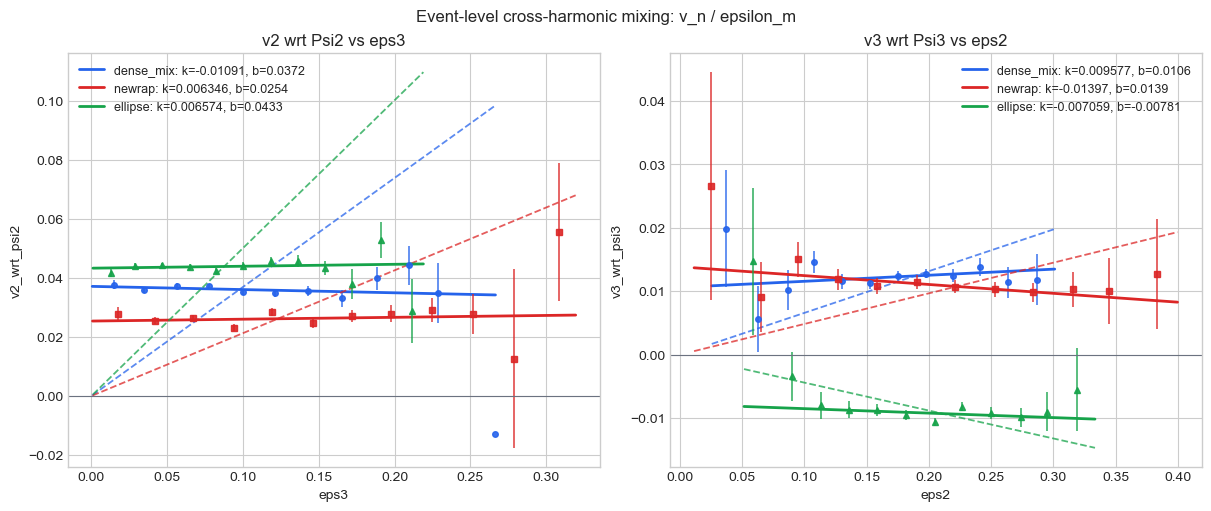

In [9]:
# Fit and compare cross-harmonic pairs as a compact diagnostic of response mixing.
CROSS_TALK_PAIRS = {
    "v2 wrt Psi2 vs eps3": {"epsilon": "eps3", "response": "v2_wrt_psi2"},
    "v3 wrt Psi3 vs eps2": {"epsilon": "eps2", "response": "v3_wrt_psi3"},
}

cross_fit_results, cross_talk_summary = fit_pair_set(CROSS_TALK_PAIRS, include_origin=True)
display(cross_talk_summary)

cross_talk_fig, cross_talk_axes = plot_pair_comparison(
    CROSS_TALK_PAIRS, cross_fit_results, "Event-level cross-harmonic mixing: v_n / epsilon_m"
)
plt.show()


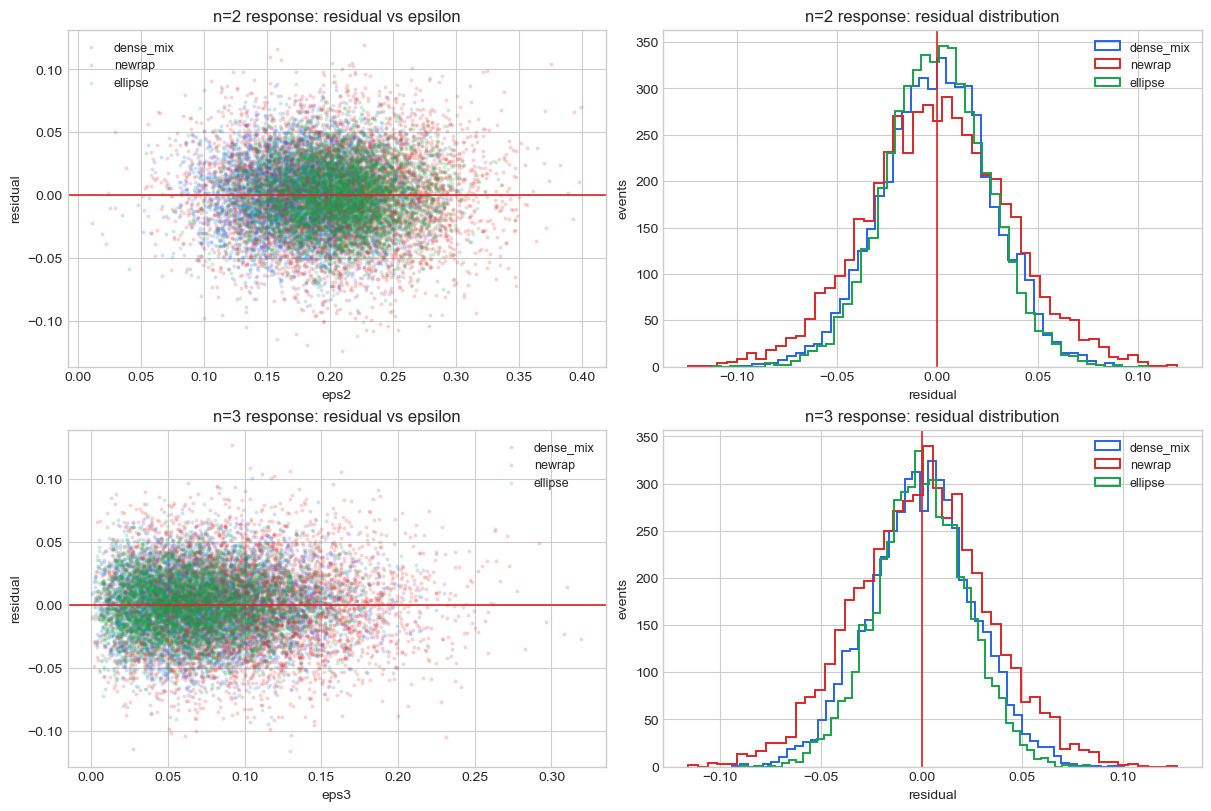

In [10]:
# Plot residuals from the same-harmonic free-intercept fits for every compared file.
def plot_residual_comparison(pair_specs: dict, all_results: dict):
    fig, axes = plt.subplots(len(pair_specs), 2, figsize=(12, 4 * len(pair_specs)), constrained_layout=True)
    axes = np.atleast_2d(axes)

    for row, (pair_label, spec) in enumerate(pair_specs.items()):
        ax_scatter, ax_hist = axes[row]
        for style_index, input_spec in enumerate(input_files):
            file_label = input_spec["label"]
            if file_label not in all_results[pair_label]:
                continue

            style = STYLE_CYCLE[style_index % len(STYLE_CYCLE)]
            data = selected_events_by_file[file_label]
            x, _, mask = finite_pair_mask(data, spec)
            x = x[mask]
            residuals = all_results[pair_label][file_label]["free"]["residuals"]

            ax_scatter.scatter(x, residuals, s=8, alpha=0.20, linewidths=0, color=style["color"], label=file_label)
            ax_hist.hist(residuals, bins=50, histtype="step", lw=1.4, color=style["color"], label=file_label)

        ax_scatter.axhline(0.0, color="#dc2626", lw=1.2)
        ax_scatter.set_title(f"{pair_label}: residual vs epsilon")
        ax_scatter.set_xlabel(spec["epsilon"])
        ax_scatter.set_ylabel("residual")
        ax_scatter.legend(frameon=False, fontsize=9)

        ax_hist.axvline(0.0, color="#dc2626", lw=1.2)
        ax_hist.set_title(f"{pair_label}: residual distribution")
        ax_hist.set_xlabel("residual")
        ax_hist.set_ylabel("events")
        ax_hist.legend(frameon=False, fontsize=9)
    return fig, axes


residual_fig, residual_axes = plot_residual_comparison(RESPONSE_PAIRS, fit_results)
plt.show()


## 可选：保存表格和图

默认不写文件。需要把结果落盘时，把 `SAVE_OUTPUTS` 改为 `True`。

In [11]:
# Persist compact regression summaries only when explicitly requested.
SAVE_OUTPUTS = False
OUTPUT_DIR = PROJECT_ROOT / "qa" / "vn_epsn_regression"

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    selection_summary.to_csv(OUTPUT_DIR / "vn_epsn_selection_summary.csv", index=False)
    summary.to_csv(OUTPUT_DIR / "vn_epsn_regression_summary.csv", index=False)
    cross_talk_summary.to_csv(OUTPUT_DIR / "vn_epsn_cross_talk_summary.csv", index=False)
    same_harmonic_fig.savefig(OUTPUT_DIR / "vn_epsn_same_harmonic_comparison.png", dpi=160)
    cross_talk_fig.savefig(OUTPUT_DIR / "vn_epsn_cross_harmonic_comparison.png", dpi=160)
    residual_fig.savefig(OUTPUT_DIR / "vn_epsn_residuals.png", dpi=160)
    print(f"Saved regression tables and comparison figures under {OUTPUT_DIR}")
else:
    print("SAVE_OUTPUTS is False; no files were written.")


SAVE_OUTPUTS is False; no files were written.
